# Enhanced NLP Pipeline for Fraud Detection of job listings


# Loading Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load data
df = pd.read_csv('data/DataSet.csv')
df = df.drop_duplicates()
df['fraudulent'] = df['fraudulent'].map({'f': 0, 't': 1})

print("Dataset loaded. Shape:", df.shape)

Dataset loaded. Shape: (17645, 18)


In [72]:
# 1. Combine text fields
text_columns = ['title', 'description', 'requirements', 'benefits']
df['combined_text'] = df[text_columns].fillna('').agg(' '.join, axis=1)

# 2. Clean the text
def clean_text(text):
    if pd.isnull(text):
        return ""
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['combined_text'].apply(clean_text)

In [73]:
# removing HTML tags to clean dataset
def clean_html(text):
    if pd.isna(text):
        return ""
    return BeautifulSoup(text, "html.parser").get_text()

text_cols = [
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_cols:
    df[col] = df[col].apply(clean_html)

## Text Feature Extraction

In [74]:
# 1. TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=5,
    max_df=0.8
)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])
print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (17645, 5000)


In [75]:
# 2. Prepare structured features
structured_features = ['telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

# Convert boolean columns to numeric
df['telecommuting'] = df['telecommuting'].map({'f': 0, 't': 1})
df['has_company_logo'] = df['has_company_logo'].map({'f': 0, 't': 1})
df['has_questions'] = df['has_questions'].map({'f': 0, 't': 1})

# Fill missing values
df['employment_type'] = df['employment_type'].fillna('Unknown')
df['required_experience'] = df['required_experience'].fillna('Unknown')
df['required_education'] = df['required_education'].fillna('Unknown')
df['industry'] = df['industry'].fillna('Unknown')
df['function'] = df['function'].fillna('Unknown')

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
le_employment = LabelEncoder()
le_experience = LabelEncoder()
le_education = LabelEncoder()
le_industry = LabelEncoder()
le_function = LabelEncoder()

df['employment_type_encoded'] = le_employment.fit_transform(df['employment_type'])
df['required_experience_encoded'] = le_experience.fit_transform(df['required_experience'])
df['required_education_encoded'] = le_education.fit_transform(df['required_education'])
df['industry_encoded'] = le_industry.fit_transform(df['industry'])
df['function_encoded'] = le_function.fit_transform(df['function'])

# Numeric features
numeric_features = ['telecommuting', 'has_company_logo', 'has_questions', 'employment_type_encoded', 'required_experience_encoded', 'required_education_encoded', 'industry_encoded', 'function_encoded']

print("Structured features prepared.")
print("Numeric features shape:", df[numeric_features].shape)

Structured features prepared.
Numeric features shape: (17645, 8)


In [76]:
# 3. Combine TF-IDF + structured features
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

X_structured = df[numeric_features].values
scaler = StandardScaler()
X_structured_scaled = scaler.fit_transform(X_structured)

X_combined = hstack([X_tfidf, X_structured_scaled])
y = df['fraudulent']

print("Combined TF-IDF + structured shape:", X_combined.shape)

Combined TF-IDF + structured shape: (17645, 5008)


## Combine Text and Structured Features

## Train-Test Split

In [77]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print("Using combined features. Train shape:", X_train.shape, "Test shape:", X_test.shape)

Using combined features. Train shape: (14116, 5008) Test shape: (3529, 5008)


## Model Training

### Method 1: Logistic Regression with balanced weights (TF-IDF)

In [78]:
# Function to evaluate model
def evaluate_model(y_true, y_pred, y_pred_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")
    
    return accuracy, precision, recall, f1, auc

# 1. Logistic Regression with class_weight balanced (TF-IDF)
print("=== Logistic Regression with balanced weights (TF-IDF) ===")
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_lr, y_pred_proba_lr)

=== Logistic Regression with balanced weights (TF-IDF) ===
Accuracy: 0.9428
Precision: 0.4531
Recall: 0.8430
F1-Score: 0.5894
AUC: 0.9710


(0.9427599886653443,
 0.453125,
 0.8430232558139535,
 0.5894308943089431,
 0.9709821892470436)

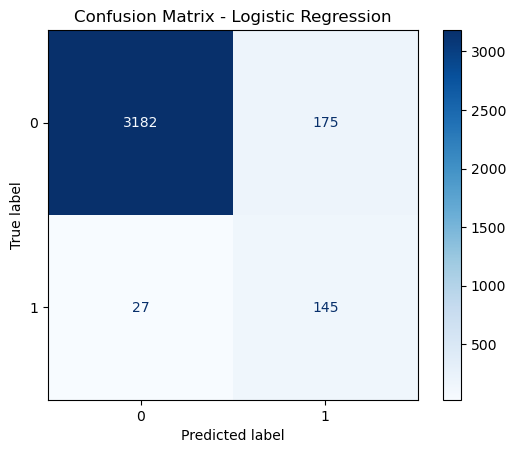

In [79]:
# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### Method 2: Random Forest with balanced weights (TF-IDF)

In [80]:
# 2. Random Forest with balanced weights (TF-IDF)
print("\n=== Random Forest with balanced weights (TF-IDF) ===")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_rf, y_pred_proba_rf)


=== Random Forest with balanced weights (TF-IDF) ===
Accuracy: 0.9756
Precision: 0.9674
Recall: 0.5174
F1-Score: 0.6742
AUC: 0.9753


(0.9756304902238595,
 0.967391304347826,
 0.5174418604651163,
 0.6742424242424242,
 0.975253029074963)

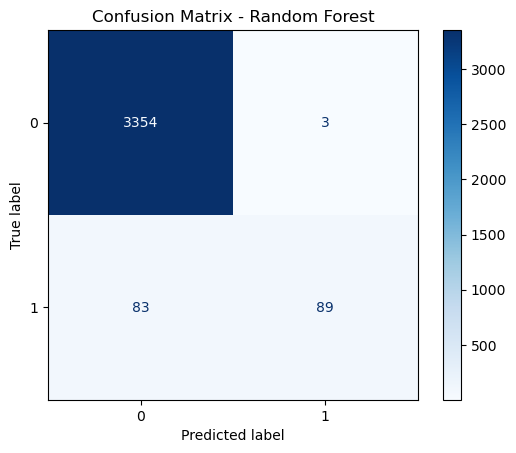

In [81]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Random Forest')
plt.show()

### Method 3: XGBoost with scale_pos_weight (TF-IDF)

In [82]:
# 3. XGBoost with scale_pos_weight (TF-IDF)
print("\n=== XGBoost with scale_pos_weight (TF-IDF) ===")
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb)


=== XGBoost with scale_pos_weight (TF-IDF) ===
Accuracy: 0.9773
Precision: 0.7949
Recall: 0.7209
F1-Score: 0.7561
AUC: 0.9728


(0.9773306885803343,
 0.7948717948717948,
 0.7209302325581395,
 0.7560975609756098,
 0.9727556442283045)

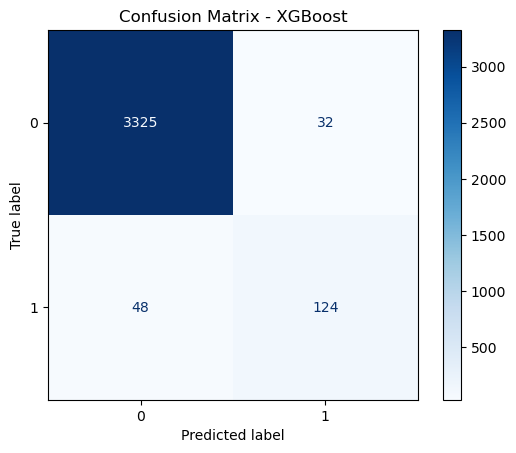

In [83]:
# Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - XGBoost')
plt.show()

## Model Evaluation

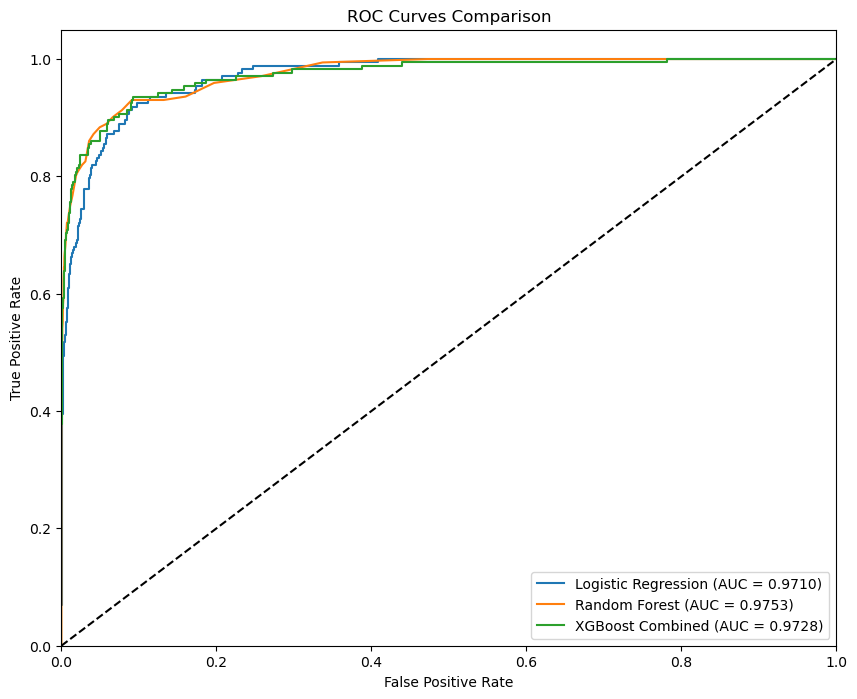


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score       AUC
0  Logistic Regression  0.942760   0.453125  0.843023  0.589431  0.970982
1        Random Forest  0.975630   0.967391  0.517442  0.674242  0.975253
2     XGBoost Combined  0.977331   0.794872  0.720930  0.756098  0.972756


In [84]:
# ROC Curves for all models
plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.4f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.4f})')

# XGBoost Combined
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost Combined (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.show()

# Summary table
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost Combined'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf), 
                 accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf),
               recall_score(y_test, y_pred_xgb)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf),
                 f1_score(y_test, y_pred_xgb)],
    'AUC': [roc_auc_score(y_test, y_pred_proba_lr), roc_auc_score(y_test, y_pred_proba_rf),
            roc_auc_score(y_test, y_pred_proba_xgb)]
}

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Summary and Recommendations

## Best Performing Model: XGBoost with TF-IDF + Structured Features
- **Accuracy**: 97.7%
- **Precision**: 79.5%
- **Recall**: 72.1%
- **F1-Score**: 75.6%
- **AUC**: 97.3%

## TLDR;
1. **Text Preprocessing**: Combined title, description, requirements, benefits; cleaned HTML, URLs, special chars
2. **Feature Engineering**: TF-IDF vectorization with 5,000 features and n-grams
3. **Structured Features**: Encoded categorical features (employment_type, industry, function, required_experience, required_education) and boolean features (telecommuting, has_company_logo, has_questions), scaled and combined with TF-IDF
4. **Class Imbalance Handling**: Used `class_weight='balanced'` for Logistic Regression and Random Forest, `scale_pos_weight` for XGBoost
5. **Model Selection**: XGBoost provided the best balance of precision and recall with combined features

## Recommendations for Further Improvement:
1. **Advanced Text Features**: Try BERT embeddings or other transformer models for better text understanding
2. **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV for optimal model parameters
3. **Ensemble Methods**: Combine multiple models (stacking, voting) for improved performance
4. **Cross-Validation**: Implement stratified k-fold CV for more robust evaluation and to prevent overfitting
5. **Feature Selection**: Use techniques like Recursive Feature Elimination (RFE) to identify most important features
6. **Model Interpretability**: Add SHAP or LIME explanations to understand model predictions